## Import Libraries

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mlflow
import mlflow.pytorch
from mlflow.entities import ViewType
from mlflow.tracking import MlflowClient
import json
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set Plotting Style
plt.style.use('default')
sns.set_palette("husl")

project_root = os.path.abspath(os.path.join(os.getcwd()))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.data_loader import get_dataloaders
from src.models.cnn_models import VanillaCNN, DeepCNN
from src.models.resnet_model import FashionResNet
from src.evaluation.evaluator import ModelEvaluator
from src.evaluation.visualization import plot_confusion_matrix
from src.utils.config import load_config
from src.utils.helpers import FASHION_MNIST_CLASSES, get_timestamp_str
print("Libraries and Custom Modules Loaded Successfully")
print(f"Root Directory: {project_root}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device Available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Libraries and Custom Modules Loaded Successfully
Root Directory: H:\VSCode\Python\fashion-mnist-classifier
PyTorch Version: 2.5.1
Device Available: CUDA
GPU Name: NVIDIA GeForce RTX 3080


## Load Configuration and Connect to MLflow

In [2]:
config_path = 'configs/config.yaml'
config = load_config(config_path)
mlflow_config = config['mlflow']
paths_config = config['paths']

# Set MLflow tracking URI
mlflow.set_tracking_uri(mlflow_config['tracking_uri'])
print(f"MLflow Tracking URI set to: {mlflow.get_tracking_uri()}")

# Set Experiment Name
mlflow.set_experiment(mlflow_config['experiment_name'])
print(f"MLflow Experiemnt set to: {mlflow_config['experiment_name']}")

# Ensure Figures Directory Exists
os.makedirs(paths_config['figures_save_dir'], exist_ok=True)
os.makedirs(os.path.join(paths_config.get('reports_save_dir', '../results/reports')), exist_ok=True)
print("Configuration Loaded and MLflow Connected")

MLflow Tracking URI set to: file:./mlruns
MLflow Experiemnt set to: Fashion MNIST Classification
Configuration Loaded and MLflow Connected


## Fetch MLflow Runs

In [3]:
runs = mlflow.search_runs(experiment_names=[mlflow_config['experiment_name']], 
                          order_by=["metrics.val_accuracy DESC"], 
                          filter_string="", 
                          output_format="pandas")

if runs.empty:
    print("No MLflow runs found. Run 'scripts/train.py' to create MLflow runs.")
else:
    print(f"Found {len(runs)} MLflow runs.")

    # Check for required column names
    if 'params.name' in runs.columns:
        model_param_col = 'params.name'
    elif 'params.model.name' in runs.columns:
        model_param_col = 'params.model.name'
    else:
        print("Could not find model name parameter in runs")
        model_param_col = None

    if model_param_col:
        display_cols = ['run_id', 'start_time', model_param_col,
                        'metrics.val_accuracy', 'metrics.val_loss']
        available_cols = [col for col in display_cols if col in runs.columns]
        display(runs[available_cols].head(10))

Found 16 MLflow runs.


,run_id,start_time,params.name,metrics.val_accuracy,metrics.val_loss
0,c9b67618ec66469d80b1712b4129181e,2025-08-09 06:03:38.170000+00:00,DeepCNN,0.9307,0.248321
1,e9f39de15ded4187a0e8066525bb18c9,2025-08-11 04:28:00.034000+00:00,FashionResNet,0.9289,0.248031
2,7df8ac2d7a3443d8a99b0a722f6ecc97,2025-08-10 16:46:29.387000+00:00,FashionResNet,0.9289,0.239966
3,ec7558cd13fc4be89f716f041c00c4b4,2025-08-13 03:55:50.266000+00:00,FashionResNet,0.9285,0.243556
4,3368218743d6488884f7093cfa39ecfa,2025-08-14 04:53:15.423000+00:00,DeepCNN,0.9282,0.292949
5,55f47d5d829b49aea4c43d2c0d1ec75e,2025-08-14 04:50:55.967000+00:00,DeepCNN,0.9267,0.251173
6,257b328ecff54b96b9cb42f1be2b6907,2025-08-10 15:04:10.632000+00:00,FashionResNet,0.9266,0.261356
7,cc06652857414e71b9066716b8bfcbac,2025-08-13 05:29:13.887000+00:00,DeepCNN,0.9265,0.285257
8,a11f28ad947a46c88aa8de6004f129e0,2025-08-14 04:48:18.329000+00:00,DeepCNN,0.9248,0.257598
9,0163549f2b984fb2b59efe324534b4f7,2025-08-11 04:42:53.040000+00:00,VanillaCNN,0.9234,0.272744


## Clean and Prepare Data for Analysis

In [4]:
# Filter for the specific models
models_to_compare = ["VanillaCNN", "DeepCNN", "FashionResNet"]

if not runs.empty:
    # Filter runs for the models
    filtered_runs = runs[runs[model_param_col].isin(models_to_compare)].copy()
    
    if filtered_runs.empty:
        print(f"No runs found for models: {models_to_compare}")
        print(f"Available model names in runs:")
        available_models = runs[model_param_col].unique()
        for model in available_models:
            print(f" {model}")
    else:
        print(f" Found {len(filtered_runs)} runs for comparison models")

        # Get best run for each model type
        best_runs_per_model = filtered_runs.loc[
                    filtered_runs.groupby(model_param_col)['metrics.val_accuracy'
                                                            ].idxmax()].copy()
        
        print("\nBest Run for Each Model:")
        comparison_df = best_runs_per_model[[model_param_col, 'metrics.val_accuracy',
                        'metrics.val_loss', 'run_id']].copy()
        comparison_df.columns = ['Model', 'Val_Accuracy', 'Val_Loss', 'Run_ID']
        comparison_df = comparison_df.sort_values('Val_Accuracy', ascending=False).reset_index(drop=True)
        display(comparison_df)

        # Store
        comparison_run_ids = comparison_df['Run_ID'].tolist()
        comparison_model_names = comparison_df['Model'].tolist()

        # Performance Statistics
        print("\nPerformance Statistics:")
        for model in models_to_compare:
            model_runs = filtered_runs[filtered_runs[model_param_col] == model]
            if not model_runs.empty:
                accuracies = model_runs['metrics.val_accuracy'].values
                print(f" {model}:")
                print(f" Best: {accuracies.max():.4f}")
                print(f" Mean: {accuracies.mean():.4f} +/- {accuracies.std():.4f}")
                print(f" Runs: {len(accuracies)}")

 Found 16 runs for comparison models

Best Run for Each Model:


,Model,Val_Accuracy,Val_Loss,Run_ID
0,DeepCNN,0.9307,0.248321,c9b67618ec66469d80b1712b4129181e
1,FashionResNet,0.9289,0.248031,e9f39de15ded4187a0e8066525bb18c9
2,VanillaCNN,0.9234,0.272744,0163549f2b984fb2b59efe324534b4f7



Performance Statistics:
 VanillaCNN:
 Best: 0.9234
 Mean: 0.9167 +/- 0.0042
 Runs: 5
 DeepCNN:
 Best: 0.9307
 Mean: 0.9274 +/- 0.0020
 Runs: 5
 FashionResNet:
 Best: 0.9289
 Mean: 0.9244 +/- 0.0057
 Runs: 6


## Visualize Performance

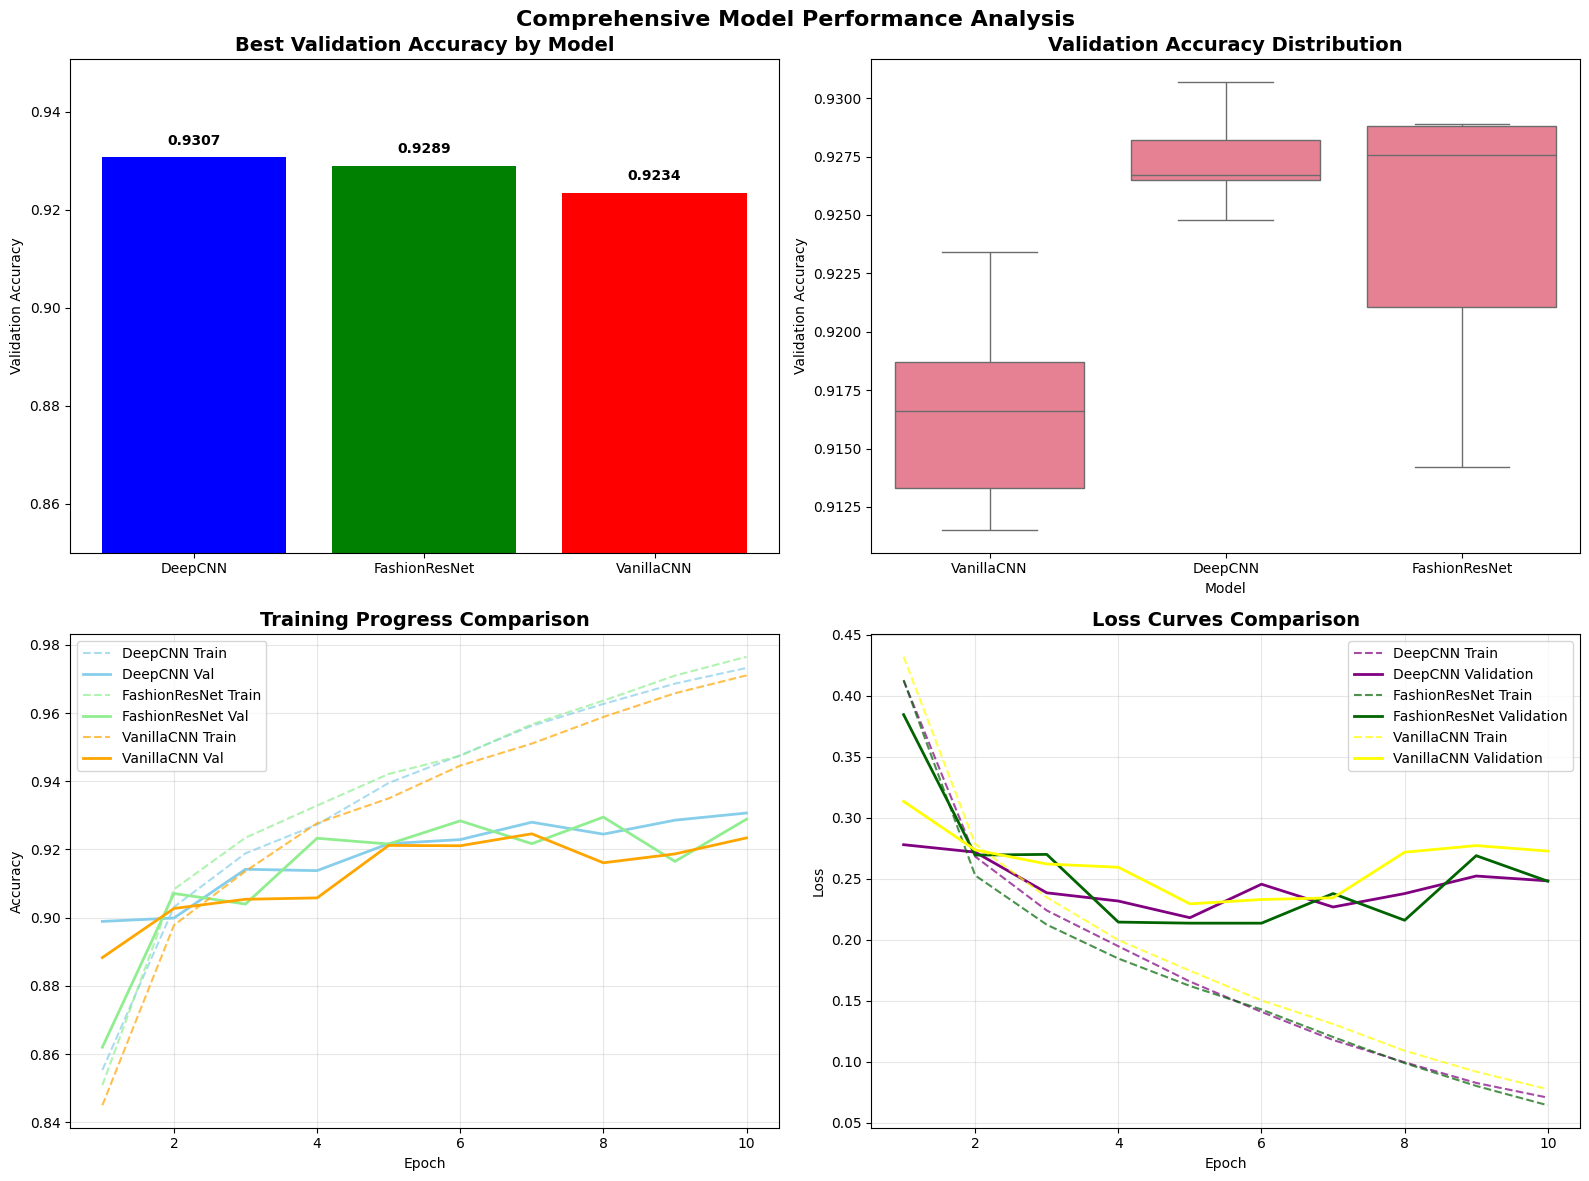

Comprehensive Comparison Plot saved to: results/figures/comprehensive_model_comparison_20250814_010131.png


In [5]:
if not filtered_runs.empty and model_param_col:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot Model Performance Comparison
    ax1 = axes[0, 0]
    models = comparison_df['Model'].values
    accuracies = comparison_df['Val_Accuracy'].values

    bars = ax1.bar(models, accuracies, color=['blue', 'green', 'red'])
    ax1.set_title('Best Validation Accuracy by Model', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Validation Accuracy')
    ax1.set_ylim(0.85, min(1.0, accuracies.max() + 0.02))

    # Bar Labels
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, height + 0.002,
        f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')


    # Plot Performance Distribution
    ax2 = axes[0,1]
    performance_data = []
    for model in models_to_compare:
        model_runs = filtered_runs[filtered_runs[model_param_col] == model]
        for _, run in model_runs.iterrows():
            performance_data.append({'Model': model, 
                                     'Accuracy':run['metrics.val_accuracy']})

    if performance_data:
        perform_df = pd.DataFrame(performance_data)
        sns.boxplot(data=perform_df, x='Model', y='Accuracy', ax=ax2)
        ax2.set_title('Validation Accuracy Distribution', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Validation Accuracy')
        
    # Plot Learning Curves
    ax3 = axes[1, 0]
    client = MlflowClient()

    for i, (model_name, run_id) in enumerate(zip(comparison_model_names, comparison_run_ids)):
        try:
            # Get Validation Accuracy History
            val_acc_history = client.get_metric_history(run_id, "val_accuracy")
            train_acc_history = client.get_metric_history(run_id, "train_accuracy")

            if val_acc_history and train_acc_history:
                val_epochs = [m.step for m in val_acc_history]
                val_accs = [m.value for m in val_acc_history]
                train_epochs = [m.step for m in train_acc_history]
                train_accs = [m.value for m in train_acc_history]

                colors = ['skyblue', 'lightgreen', 'orange']
                ax3.plot(train_epochs, train_accs, f'--', color=colors[i],
                        alpha=0.7, label=f'{model_name} Train')
                ax3.plot(val_epochs, val_accs, f'-', color=colors[i],
                        linewidth=2, label=f'{model_name} Val')
        except Exception as e:
            print(f"Could not fetch history for {model_name}: {e}")

    ax3.set_title('Training Progress Comparison', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot Loss Curves Comparison
    ax4 = axes[1, 1]
    for i, (model_name, run_id) in enumerate(zip(comparison_model_names, comparison_run_ids)):
        try:
            val_loss_history = client.get_metric_history(run_id, "val_loss")
            train_loss_history = client.get_metric_history(run_id, "train_loss")

            if val_loss_history and train_loss_history:
                val_epochs = [m.step for m in val_loss_history]
                val_losses = [m.value for m in val_loss_history]
                train_epochs = [m.step for m in train_loss_history]
                train_losses = [m.value for m in train_loss_history]

                colors = ['purple','darkgreen','yellow']
                ax4.plot(train_epochs, train_losses, f'--', color=colors[i],
                        alpha=0.7, label=f'{model_name} Train')
                ax4.plot(val_epochs, val_losses, f'-', color=colors[i],
                        linewidth=2, label=f'{model_name} Validation')

        except Exception as e:
            print(f"Could not fetch loss history for {model_name}: {e}")

    ax4.set_title('Loss Curves Comparison', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Comprehensive Model Performance Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()

    # Save Comprehensive plot
    timestamp = get_timestamp_str()
    comprehen_plot_path = os.path.join(paths_config['figures_save_dir'],
                                    f'comprehensive_model_comparison_{timestamp}.png')
    plt.savefig(comprehen_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Comprehensive Comparison Plot saved to: {comprehen_plot_path}")

## Metrics and Artifacts for Best Model

In [6]:
if not filtered_runs.empty:
    summary_data = []
    for model_name, run_id in zip(comparison_model_names, comparison_run_ids):
        # Fetch specific run object
        run = mlflow.get_run(run_id)

        # Extract info
        params = run.data.params
        metrics = run.data.metrics

        # Get classification report artifact
        client = mlflow.tracking.MlflowClient()
        artifacts = client.list_artifacts(run_id, "evaluation_results")
        report_artifact = next((a for a in artifacts if a.path.endswith('.json') and 'evaluation_metrics' in a.path), None)

        if report_artifact:
            # Load JSON
            report_path = client.download_artifacts(run_id, report_artifact.path)
            with open(report_path, 'r') as f:
                eval_metrics = json.load(f)

            # Extract avg F1-score
            macro_f1 = eval_metrics['classification_report_dict']['macro avg']['f1-score']
        else:
            eval_metrics = {}
            macro_f1 = np.nan

        summary_data.append({"Model": model_name, "Run ID": run_id, "Val Accuracy": f"{metrics.get('val_accuracy', 0):.4f}", "Val Loss": f"{metrics.get('val_loss', 0):.4f}",
                            "Test Accuracy": f"{eval_metrics.get('overall_accuracy', 0):.4f}", "Test F1-Score (Macro Avg)": f"{macro_f1:.4f}", "Epochs Trained": f"{metrics.get('epoch', 0):.0f}",
                            "Learning Rate": params.get('training.learning_rate')})
        summary_df = pd.DataFrame(summary_data)
        display(summary_df)

print("===== Model Selection and Observations =====")
print("Based on the comparison:")
print(" The VanillaCNN serves as a good baseline.")
print(" The DeepCNN generally shows improved performance over VAnillaCNN.")
print(" FashionResNet often achieves the highest accuracy and tends to converge faster, demonstrating the power of residual connections.")

,Model,Run ID,Val Accuracy,Val Loss,Test Accuracy,Test F1-Score (Macro Avg),Epochs Trained,Learning Rate
0,DeepCNN,c9b67618ec66469d80b1712b4129181e,0.9307,0.2483,0.0000,nan,0,None


,Model,Run ID,Val Accuracy,Val Loss,Test Accuracy,Test F1-Score (Macro Avg),Epochs Trained,Learning Rate
0,DeepCNN,c9b67618ec66469d80b1712b4129181e,0.9307,0.2483,0.0000,nan,0,None
1,FashionResNet,e9f39de15ded4187a0e8066525bb18c9,0.9289,0.2480,0.0000,nan,0,None


,Model,Run ID,Val Accuracy,Val Loss,Test Accuracy,Test F1-Score (Macro Avg),Epochs Trained,Learning Rate
0,DeepCNN,c9b67618ec66469d80b1712b4129181e,0.9307,0.2483,0.0000,nan,0,None
1,FashionResNet,e9f39de15ded4187a0e8066525bb18c9,0.9289,0.2480,0.0000,nan,0,None
2,VanillaCNN,0163549f2b984fb2b59efe324534b4f7,0.9234,0.2727,0.0000,nan,0,None


===== Model Selection and Observations =====
Based on the comparison:
 The VanillaCNN serves as a good baseline.
 The DeepCNN generally shows improved performance over VAnillaCNN.
 FashionResNet often achieves the highest accuracy and tends to converge faster, demonstrating the power of residual connections.


## Model Comparison Analysis Summary

### Performance Ranking
Based on validation accuracy, the models rank as follows:
1. **DeepCNN** - 93.07%
2. **FashionResNet** - 92.89%  
3. **VanillaCNN** - 92.34%

### Key Insights
- **Architecture Impact**: The DeepCNN architecture demonstrates the power of batch normalization, dropout regularization, and the additional layer for this image classification task.